#### By: Thandokuhle Brian Msane

# K-means Clutering

In the clustering problem, we are given a training set {x<sup>(i)</sup>, ..., x<sup>(n)</sup>} and want to group the data into a few cohesive clusters. Here, we do not have the label y<sup>(i)</sup> so it is an unsupervised learning problem.

The k-means clustering algorithm is a follows:

1. Initiate cluster centriods u<sub>i</sub>, ..., u<sub>k</sub> randomly
2. Repeat until convergence: {\
    for every i, set\
        c<sup>(i)</sub> := arg min || x<sup>(i)</sup> - u<sub>j</sub> || <sup>2</sup> \
    for every j, set\
        u<sup>j</sup> := <sub>n</sub> &sum <sup>n=1</sup>
}

## Intuitively

To easily understand this, it is important to note that the objective of clustering is to maximize the similarity of objects which are in the same cluster such that they become more similar to each other while also making sure that they are very different to those in different clusters. This definition introduces similarity and dissimilarity or proximity measures of values. To make things easy it is important to first look at numerical numbers.

The proximity measures of numerical values can be determined by using one of the following methods.
- Euclidean distance. This can be thought of as the distance of a straight line
- Manhattan distance. 
- Minkowski distance. Generalization of Euclidean and Manhattan distances.

TODO: write formulas in latex or markdown


In [ ]:
import math
import matplotlib.pyplot as plt
from pprint import pprint


import pandas as pd
from sklearn.cluster import KMeans

In [ ]:
input = [(2,10), (2,5), (8, 4), (5, 8), (7,5), (6, 4), (1, 2), (4, 9), (7,2), (5, 4), (8, 3), (9,0)]

def euclidean_distance(
    X: tuple[float],
    Y: tuple[float],
    p: int | None = None
) -> float:
    """Compute the Euclidean distance between X and Y where they are data objects characterized by p attributes"""
    
    assert len(X) == len(Y), "Both X and Y should be of the same size"
    
    if not p:
        p = len(X)
    
    squares = 0
    for i in range(0, p):
        squares += (X[i] - Y[i])**2
    return math.sqrt(squares)

def manhattan_distance(
    X: tuple[float],
    Y: tuple[float],
    p: int| None = None
) -> float:
    assert len(X) == len(Y), "Both X and Y should be of the same size"
    
    if not p:
        p = len(X)
    absolutes = 0
    for i in range(0, p):
        absolutes += abs(X[i] - Y[i])
    return absolutes

print(euclidean_distance((1,2), (3,5)))
print(manhattan_distance((1,2), (3,5)))

3.605551275463989
5


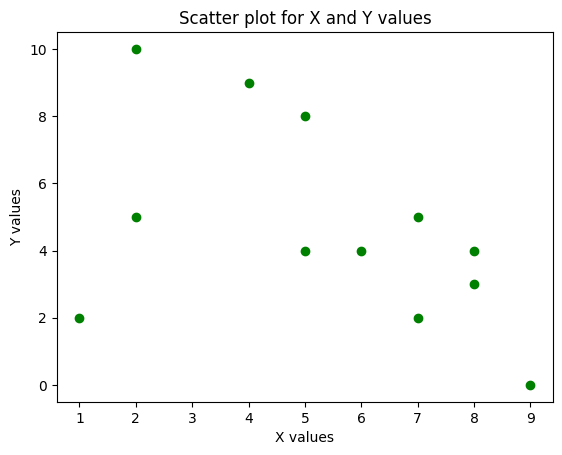

In [84]:
x = []
y = []

for item in input:
    x.append(item[0])
    y.append(item[1])

plt.plot(x, y, 'o', color="green")
plt.xlabel("X values")
plt.ylabel("Y values")
plt.title("Scatter plot for X and Y values")
plt.show()


So, now that we can compute the distances we can then be able to perform the clustering using k-means but this is going to require some information which includes:

- **k**: This is the parameter of the algorithm which shows the number of clusters we want to find. The question to ask is, "how do you determine the correct value for your k parameter?" To determine it, we normally use an elbow chart
- **initial centriods**: A centriod is the center of a cluster. The algorithm requires that we have these so we can randomly select some of the data values to be these initial centriods/seeds.



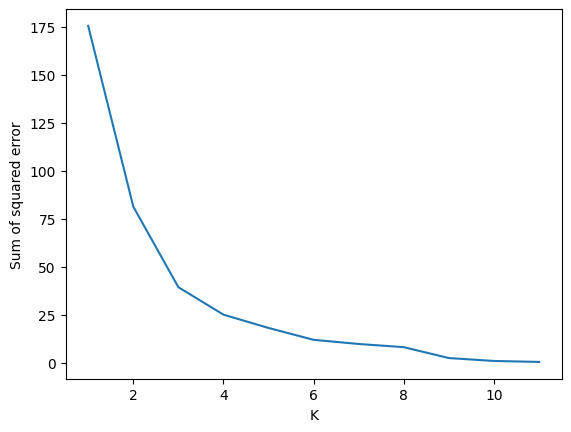

In [ ]:

df = pd.DataFrame(data={"x": x, "y": y})

k_range = range(1, len(x))
sse = []

for k in k_range:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(df[['x', 'y']])
    sse.append(kmeans.inertia_)

plt.xlabel('K')
plt.ylabel('Sum of squared error')
plt.plot(k_range, sse)
plt.show()


In [ ]:

k = 3
initial_centriod1 = (2,10)
initial_centriod2 = (5,8)
initial_centriod3 = (1,2)



cluster1 = []
cluster2 = []
cluster3= []

for object in input:
    distance1 = euclidean_distance(initial_centriod1, object)
    distance2 = euclidean_distance(initial_centriod2, object)
    distance3 = euclidean_distance(initial_centriod3, object)
    
    object_distances = [distance1, distance2, distance3]
    cluster = object_distances.index(min(object_distances))

    if cluster == 0:
        cluster1.append(object)
    elif cluster == 1:
        cluster2.append(object)
    elif cluster == 2:
        cluster3.append(object)

    print(f"{object} belongs to cluster {cluster + 1}")

print('\n\n')
pprint(cluster1)
pprint(cluster2)
pprint(cluster3)
print('\n\n')



for index, cluster in enumerate([cluster1, cluster2, cluster3]):
    sum_of_x = 0
    sum_of_y = 0
    
    for object in cluster:
        x = object[0]
        y = object[1]
        
        sum_of_x += x
        sum_of_y += y
    
    print(f"The new centriod for cluster {index + 1} is ({round(sum_of_x/len(cluster), 2)}, {round(sum_of_y / len(cluster), 2)})")
    

(2, 10) belongs to cluster 1
(2, 5) belongs to cluster 3
(8, 4) belongs to cluster 2
(5, 8) belongs to cluster 2
(7, 5) belongs to cluster 2
(6, 4) belongs to cluster 2
(1, 2) belongs to cluster 3
(4, 9) belongs to cluster 2
(7, 2) belongs to cluster 3
(5, 4) belongs to cluster 2
(8, 3) belongs to cluster 2
(9, 0) belongs to cluster 3



[(2, 10)]
[(8, 4), (5, 8), (7, 5), (6, 4), (4, 9), (5, 4), (8, 3)]
[(2, 5), (1, 2), (7, 2), (9, 0)]



The new centriod for cluster 1 is (2.0, 10.0)
The new centriod for cluster 2 is (6.14, 5.29)
The new centriod for cluster 3 is (4.75, 2.25)


This is only one epoch and we did the following steps:

1. Compute the distance between each data object and all the clusters which we randomly initialized
2. Determine and assign an object to the cluster which it has the smallest distance with. The smallest distance means that the object is more similar to that centriod therefore it is said to be similar to the objects which are in that cluster.
3. Recompute the new centriod values which are the mean of the items assigned to the cluster.
 
The formula above tells us that we need to change both items that belong to a cluster and the centriods until convergence. This means that the computation should go on until we do not see any change in both the centriod values and the cluster items. Therefore, we are required, often times, to do more than one iteration or epoch and we need a solution that is robust enough to determine when convergence has occurred and also perform the iterations which are specified by the user. Let's define the class below to try to attain this.

In [ ]:
import pandas as pd

class KMeans:
    def __init__(
        self,
        k: int,
        data: pd.DataFrame | list[tuple],
        initial_centriods: list[tuple] | None = None
    ): 
        self._k = k
        
    def fit(self):
        return self